<a href="https://colab.research.google.com/github/mirian2004/AI-AI-/blob/Day04/Day4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# 1. 데이터 준비 (AI 모델의 마지막 레이어 출력값이라 가정)
# 상황: [강아지, 고양이, 토끼] 일 확률을 예측하는 모델
labels = ['Dog', 'Cat', 'Rabbit']
logits = np.array([3.5, 1.2, -0.5])

print(f"1. 모델의 원시 출력값(Logit): {logits}")

1. 모델의 원시 출력값(Logit): [ 3.5  1.2 -0.5]


In [ ]:
# 2. Softmax 함수 정의 (Temperature 포함)
def softmax_with_temperature(logits, temperature=1.0):
    exp_logits = np.exp((logits) / temperature)
    return exp_logits / np.sum(exp_logits)

print(softmax_with_temperature(logits))

[0.893995   0.08963091 0.01637409]



2. Temperature 변화에 따른 확률 분포:
Temp 0.5: [0.99 0.01 0.  ] -> 가장 높은 확률: Dog
Temp 1.0: [0.894 0.09  0.016] -> 가장 높은 확률: Dog
Temp 5.0: [0.481 0.303 0.216] -> 가장 높은 확률: Dog


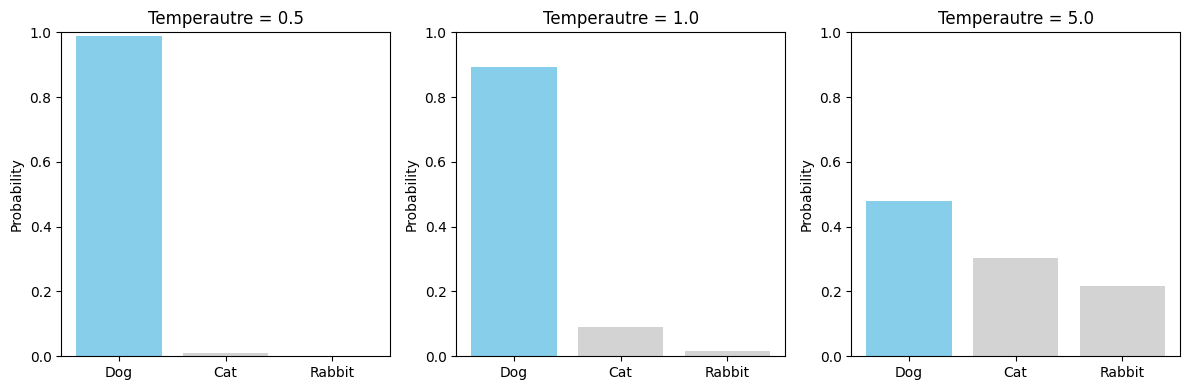

In [ ]:
# 3. 실험: Temperature 변화에 따른 확률 분포 관착
temps = [0.5, 1.0, 5.0]
results = []

print("\n2. Temperature 변화에 따른 확률 분포:")
plt.figure(figsize=(12, 4))

for i, T in enumerate(temps):
    probs = softmax_with_temperature(logits, T)
    results.append(probs)

    #텍스트 출력
    print(f"Temp {T}: {np.round(probs,3)} -> 가장 높은 확률: {labels[np.argmax(probs)]}")

    #그래프 그리기
    plt.subplot(1, 3, i+1)
    plt.bar(labels, probs, color=['skyblue', 'lightgray', 'lightgray'])
    plt.title(f"Temperautre = {T}")
    plt.ylim(0, 1.0)
    plt.ylabel("Probability")

plt.tight_layout()
plt.show()

In [ ]:
# 4. Entropy(엔트로피) 계산 실습
# Entropy 함수 정의
def calculate_entropy(probabilities):
    #log(0) 방지를 위해 아주 작은 값(delta)을 더함
    delta = 1e-7
    return -np.sum(probabilities * np.log(probabilities + delta))

print("\n3. Temperature 변화에 따른 Entropy(불확실성) 계산:")

for i, T in enumerate(temps):
  probs = results[i]
  entropy = calculate_entropy(probs)
  print(f"Temp: {T}: Probilities {np.round(probs,3)} -> Entropy: {entropy:.4f} (불확실성)")


3. Temperature 변화에 따른 Entropy(불확실성) 계산:
Temp: 0.5: Probilities [0.99 0.01 0.  ] -> Entropy: 0.0588 (불확실성)
Temp: 1.0: Probilities [0.894 0.09  0.016] -> Entropy: 0.3837 (불확실성)
Temp: 5.0: Probilities [0.481 0.303 0.216] -> Entropy: 1.0450 (불확실성)


In [ ]:
# 5. Cross-Entropy 계산 실습
def cross_entropy_error(y_pred, y_true_index):
    #log(0) 방지를 위해 아주 작은 값(delta)을 더함
    delta = 1e-7
    return -np.log(y_pred[y_true_index]+delta)

# Case A: 실제 정답이 '강아지(Index 0)' 일때
true_label_index = 0

print("\n4. Cross-Entropy 계산:")

pred = results[1]
loss_good = cross_entropy_error(pred,true_label_index)
print(f"Case A (정답이 강아지일 때): 강아지 확률 {pred[0]:.2f} -> CE: {loss_good:.4f}")

# Case B: 실제 정답이 '고양이(Index 1)' 일때
true_label_index = 1
loss_bad = cross_entropy_error(pred,true_label_index)
print(f"Case B (정답이 고양이일 때): 고양이 확률 {pred[1]:.2f} -> CE: {loss_bad:.4f}")


4. Cross-Entropy 계산:
Case A (정답이 강아지일 때): 강아지 확률 0.89 -> CE: 0.1121
Case B (정답이 고양이일 때): 고양이 확률 0.09 -> CE: 2.4121
